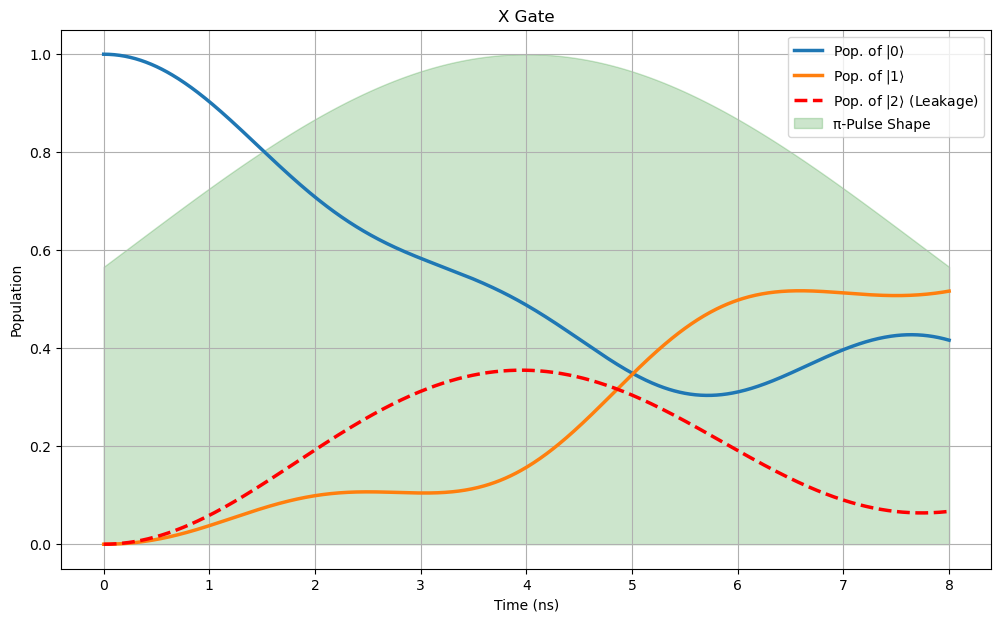

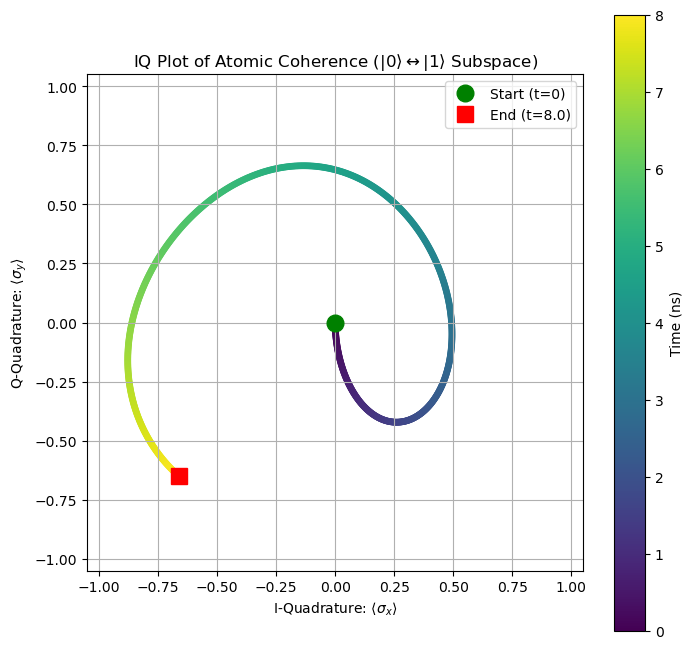


--- Generating Experimental Readout IQ Plot (with Blobs) ---
Final State: 41.6% |0>, 51.7% |1>
Readout classifies 44.6% of measured shots as |0> and 55.4% as |1>


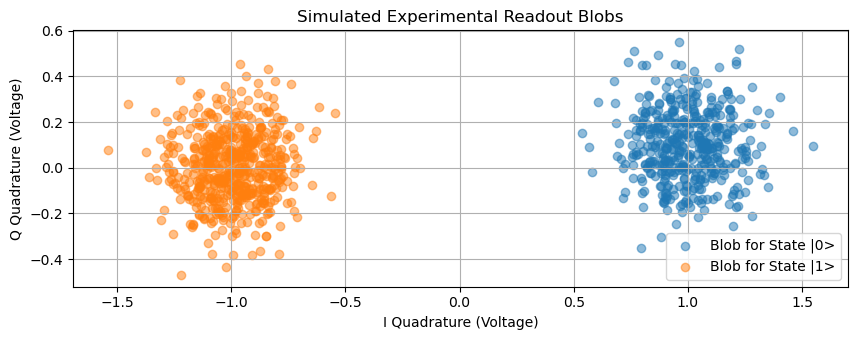

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
import time

# ==============================================================================
# READOUT PLOT FUNCTION 
# ==============================================================================
def generate_readout_blobs(p0_final, p1_final, num_shots=1000, noise_level=0.15):
    """
    Simulates an experimental IQ readout by generating noisy data points
    based on the final probabilities of being in state |0> or |1>.
    """
    print("\n--- Generating Experimental Readout IQ Plot (with Blobs) ---")
    total_pop_01 = p0_final + p1_final
    if total_pop_01 < 1e-6:
        print("Warning: All population has leaked out of the |0>,|1> subspace.")
        p0_norm, p1_norm = 0, 0
    else:
        p0_norm = p0_final / total_pop_01
        p1_norm = p1_final / total_pop_01
    
    print(f"Final State: {p0_final*100:.1f}% |0>, {p1_final*100:.1f}% |1>")
    print(f"Readout classifies {p0_norm*100:.1f}% of measured shots as |0> and {p1_norm*100:.1f}% as |1>")

    center_0 = np.array([1.0, 0.1])
    center_1 = np.array([-1.0, 0.0])
    num_shots_0 = int(np.round(p0_norm * num_shots))
    num_shots_1 = num_shots - num_shots_0
    
    blob_0_I = np.random.normal(loc=center_0[0], scale=noise_level, size=num_shots_0)
    blob_0_Q = np.random.normal(loc=center_0[1], scale=noise_level, size=num_shots_0)
    blob_1_I = np.random.normal(loc=center_1[0], scale=noise_level, size=num_shots_1)
    blob_1_Q = np.random.normal(loc=center_1[1], scale=noise_level, size=num_shots_1)

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(blob_0_I, blob_0_Q, alpha=0.5, label='Blob for State |0>')
    ax.scatter(blob_1_I, blob_1_Q, alpha=0.5, label='Blob for State |1>')
    ax.set_title("Simulated Experimental Readout Blobs")
    ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)")
    ax.grid(True); ax.legend(); ax.set_aspect('equal', adjustable='box')
    plt.show()

#=============================================================================
def simulate_permanent_gate_with_leakage():
    """
    Achieves a permanent |0>->|1> state transfer by calibrating the pulse
    to be slightly weaker, preventing over-rotation caused by the leakage.
    """
   

    # --- 1. SETUP ---
    N_atom = 3
    N_field = 4
    
    w_b1 = 5.0 * 2 * np.pi   
    w_b2 = 4.9 * 2 * np.pi   
    w_a = 6.0 * 2 * np.pi    
    Omega1 = 1.1 * 2 * np.pi 
    Omega2 = 4.99 * 2 * np.pi
    
    # We'll use a weak but non-zero leakage coupling
    lambda1 = 0.04 * 2 * np.pi 
    lambda2 = 0.0

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    sm_ab1_bare = basis(N_atom, 0) * basis(N_atom, 2).dag()
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    a1 = tensor(qeye(N_atom), a_bare, qeye(N_field))
    a2 = tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_ab1 = tensor(sm_ab1_bare, qeye(N_field), qeye(N_field))
    sm_01 = tensor(sm_01_bare, qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    P_b1 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field))
    P_b2 = tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    I_op_bare = sm_01_bare + sm_01_bare.dag()
    Q_op_bare = -1j * sm_01_bare + 1j * sm_01_bare.dag()
    I_op = tensor(I_op_bare, qeye(N_field), qeye(N_field))
    Q_op = tensor(Q_op_bare, qeye(N_field), qeye(N_field))

    # --- 3. Construct the Static Hamiltonian ---
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_interaction = lambda1 * (a1.dag() * sm_ab1 + a1 * sm_ab1.dag()) 
    H_static_quantum = H_atom + H_fields + H_interaction

    # --- 4. Define the Gaussian π-Pulse ---
    pulse_duration = 15.0
    pulse_sigma = pulse_duration / 4.0
    pulse_t0 = 4.0
    
   
    required_area = np.pi # Use 98% of a perfect pi-pulse area
    pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    drive_freq_01 = w_b1 - w_b2
    
    H_drive_01_op = sm_01 + sm_01.dag()
    drive_args = {'A': pulse_amplitude, 't0': pulse_t0, 'sigma': pulse_sigma, 'w': drive_freq_01}
    gaussian_coeff = lambda t, args: args['A'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w'] * t)

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [H_static_quantum, [H_drive_01_op, gaussian_coeff]]

    # --- 6. Initial State ---
    psi0 = tensor(basis(N_atom, 0), basis(N_field, 1), coherent(N_field, 0))
    c_ops = []

    # --- 7. SIMULATION & ANALYSIS ---
    tlist = np.linspace(0, 8.0, 801)
    e_ops = [P_b1, P_b2, P_a, I_op, Q_op]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. Data Extraction ---
    pop_0 = result.expect[0]
    pop_1 = result.expect[1]
    pop_2 = result.expect[2] 
    I_vals = result.expect[3]
    Q_vals = result.expect[4]

    # --- 9. Plotting ---
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', color='red', linestyle='--')
    
    pulse_envelope = [np.exp(-(t - pulse_t0)**2 / (2 * pulse_sigma**2)) for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_envelope, color='green', alpha=0.2, label='π-Pulse Shape')
    
    ax_p.set_title("X Gate")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    fig_iq, ax_iq = plt.subplots(figsize=(8, 8))
    points = ax_iq.scatter(I_vals, Q_vals, c=tlist, cmap='viridis', s=15)
    plt.colorbar(points, ax=ax_iq, label='Time (ns)')
    ax_iq.plot(I_vals[0], Q_vals[0], 'go', markersize=12, label='Start (t=0)')
    ax_iq.plot(I_vals[-1], Q_vals[-1], 'rs', markersize=12, label=f'End (t={tlist[-1]})')
    ax_iq.set_title(r"IQ Plot of Atomic Coherence ($|0\rangle \leftrightarrow |1\rangle$ Subspace)")
    ax_iq.set_xlabel(r"I-Quadrature: $\langle\sigma_x\rangle$")
    ax_iq.set_ylabel(r"Q-Quadrature: $\langle\sigma_y\rangle$")
    ax_iq.grid(True), ax_iq.set_aspect('equal', adjustable='box'), ax_iq.set_xlim(-1.05, 1.05), ax_iq.set_ylim(-1.05, 1.05), ax_iq.legend()
    plt.show()

    final_pop_0 = pop_0[-1]
    final_pop_1 = pop_1[-1]
    generate_readout_blobs(final_pop_0, final_pop_1)

if __name__ == '__main__':
    simulate_permanent_gate_with_leakage()

--- Simulating a Corrected Hadamard Gate (Y/2 Pulse) with Leakage ---


C:\Users\HP\anaconda3\lib\site-packages\qutip\solver\solver_base.py:576: FutureWarning: e_ops will be keyword only from qutip 5.3 for all solver
  warnings.warn(


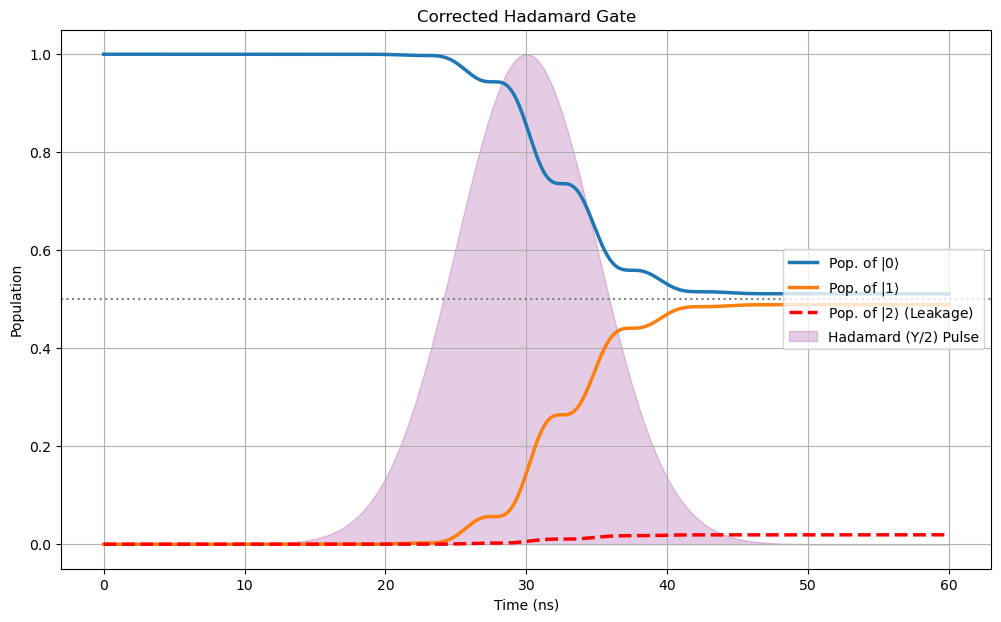


--- Generating IQ Plot from Bloch Vector ---


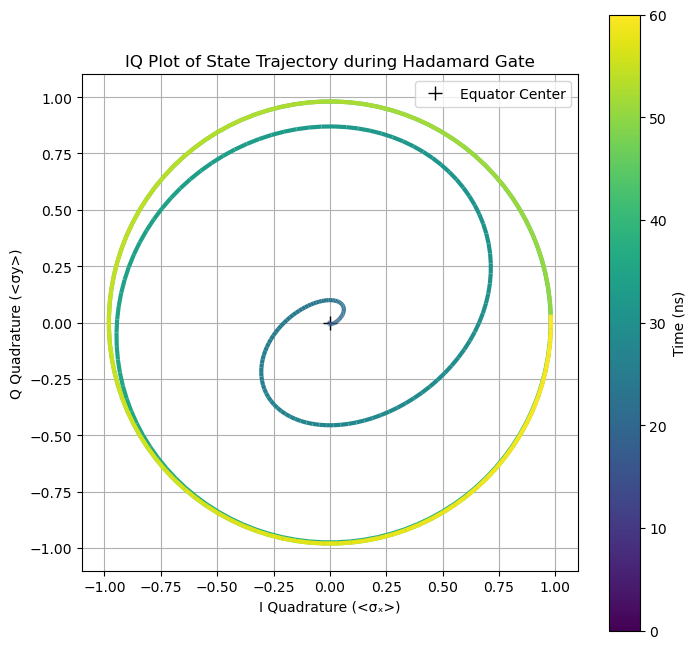


--- Generating CORRECT Experimental Readout IQ Plot ---
Final State: 51.1% |0>, 48.9% |1>, 1.9% |2>
Simulating 1000 measurements:
 - 511 will be measured as |0>
 - 489 will be measured as |1>


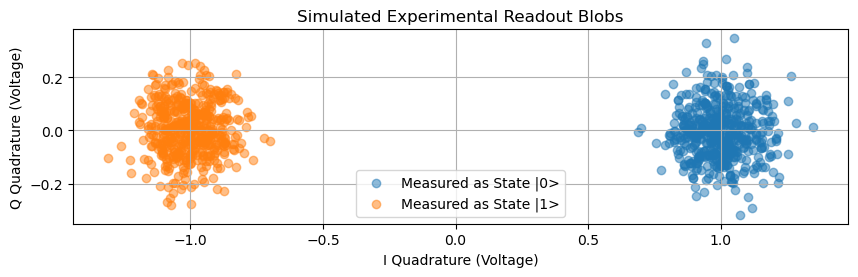

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from qutip import (
    tensor, qeye, destroy, basis, mesolve, coherent
)
from matplotlib.collections import LineCollection
import time

# (These plotting functions are correct and unchanged)
def plot_iq_trajectory_bloch(result, tlist):
    print("\n--- Generating IQ Plot from Bloch Vector ---")
    I_traj = result.expect[0]
    Q_traj = result.expect[1]
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.plot(0, 0, 'k+', markersize=10, label='Equator Center')
    points = np.array([I_traj, Q_traj]).T.reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    cmap = plt.get_cmap('viridis')
    lc = LineCollection(segments, cmap=cmap, norm=plt.Normalize(0, tlist.max()))
    lc.set_array(tlist)
    lc.set_linewidth(3)
    line = ax.add_collection(lc)
    fig.colorbar(line, ax=ax, label='Time (ns)')
    ax.set_title("IQ Plot of State Trajectory during Hadamard Gate")
    ax.set_xlabel("I Quadrature (<σₓ>)"), ax.set_ylabel("Q Quadrature (<σy>)")
    ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    ax.set_xlim(-1.1, 1.1), ax.set_ylim(-1.1, 1.1)
    plt.show()

def plot_measurement_blobs_corrected(result):
    print("\n--- Generating CORRECT Experimental Readout IQ Plot ---")
    pop0_final = (1 + result.expect[2][-1]) / 2.0
    pop1_final = (1 - result.expect[2][-1]) / 2.0
    if len(result.expect) > 3:
        pop2_final = result.expect[3][-1]
        print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>, {pop2_final*100:.1f}% |2>")
    else:
        print(f"Final State: {pop0_final*100:.1f}% |0>, {pop1_final*100:.1f}% |1>")

    iq_0, iq_1 = (1.0, 0.0), (-1.0, 0.0)
    noise_std_dev, total_shots = 0.1, 1000
    shots_in_0 = int(round(pop0_final * total_shots))
    shots_in_1 = total_shots - shots_in_0
    
    print(f"Simulating {total_shots} measurements:")
    print(f" - {shots_in_0} will be measured as |0>"), print(f" - {shots_in_1} will be measured as |1>")
    if shots_in_0 + shots_in_1 < total_shots:
        print(f" - {total_shots - (shots_in_0 + shots_in_1)} were lost to leakage and not measured.")
        
    data_0_I, data_0_Q = np.random.normal(iq_0[0], noise_std_dev, shots_in_0), np.random.normal(iq_0[1], noise_std_dev, shots_in_0)
    data_1_I, data_1_Q = np.random.normal(iq_1[0], noise_std_dev, shots_in_1), np.random.normal(iq_1[1], noise_std_dev, shots_in_1)
    fig, ax = plt.subplots(figsize=(10, 8))
    if shots_in_0 > 0: ax.scatter(data_0_I, data_0_Q, alpha=0.5, label=f'Measured as State |0>')
    if shots_in_1 > 0: ax.scatter(data_1_I, data_1_Q, alpha=0.5, label=f'Measured as State |1>')
    ax.set_title("Simulated Experimental Readout Blobs"), ax.set_xlabel("I Quadrature (Voltage)")
    ax.set_ylabel("Q Quadrature (Voltage)"), ax.set_aspect('equal', 'box'), ax.grid(True), ax.legend()
    plt.show()

# ==============================================================================
# FINAL, CORRECTED SIMULATION FOR A HADAMARD GATE
# ==============================================================================
def simulate_hadamard_gate_final_corrected():
    """
    Runs a CORRECT Hadamard gate simulation (a single Y/2 pulse)
    with drive-induced leakage.
    """
    print("--- Simulating a Corrected Hadamard Gate (Y/2 Pulse) with Leakage ---")

    # --- 1. SETUP ---
    N_atom, N_field = 3, 4
    w_b1, w_b2, w_a = 5.0 * 2 * np.pi, 4.9 * 2 * np.pi, 5.1 * 2 * np.pi
    Omega1, Omega2 = 5.0 * 2 * np.pi, 4.99 * 2 * np.pi
    lambda1, lambda2 = 0.0, 0.0

    # --- 2. Define Operators ---
    a_bare = destroy(N_field)
    a1, a2 = tensor(qeye(N_atom), a_bare, qeye(N_field)), tensor(qeye(N_atom), qeye(N_field), a_bare)
    sm_01_bare = basis(N_atom, 0) * basis(N_atom, 1).dag()
    
    # Main gate operator is a Y-rotation
    sigma_y_bare = -1j * (sm_01_bare - sm_01_bare.dag())
    sigma_y_op = tensor(sigma_y_bare, qeye(N_field), qeye(N_field))
    
    # Leakage operator
    leakage_op_bare = basis(N_atom, 0) * basis(N_atom, 2).dag() + basis(N_atom, 2) * basis(N_atom, 0).dag()
    leakage_op = tensor(leakage_op_bare, qeye(N_field), qeye(N_field))
    
    # Measurement operators
    sigma_x_op = tensor(sm_01_bare + sm_01_bare.dag(), qeye(N_field), qeye(N_field))
    sigma_z_op = tensor(basis(N_atom, 0).proj() - basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    P_a = tensor(basis(N_atom, 2).proj(), qeye(N_field), qeye(N_field))
    
    # --- 3. Construct the Static Hamiltonian ---
    P_b1, P_b2 = tensor(basis(N_atom, 0).proj(), qeye(N_field), qeye(N_field)), tensor(basis(N_atom, 1).proj(), qeye(N_field), qeye(N_field))
    H_atom = w_a * P_a + w_b1 * P_b1 + w_b2 * P_b2
    H_fields = Omega1 * a1.dag() * a1 + Omega2 * a2.dag() * a2
    H_static_quantum = H_atom + H_fields

    # --- 4. Define the Drive Pulses ---
    # <<< THE FIX IS HERE: A SINGLE, CALIBRATED Y/2 PULSE >>>
    pulse_duration, pulse_t0 = 20.0, 30.0
    pulse_sigma = pulse_duration / 4.0
    
    # Calibrate the Y/2 pulse area, with a slight reduction to prevent over-rotation
    required_area = (np.pi / 2.0) * 0.98 
    y_pulse_amplitude = required_area / (pulse_sigma * np.sqrt(2 * np.pi))
    
    drive_freq_01 = w_b1 - w_b2
    y_drive_coeff = lambda t, args: args['A_y'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w_d'] * t)

    # Leakage crosstalk happens during this single pulse
    leakage_amplitude = y_pulse_amplitude * 0.2 
    leakage_freq = w_b1 - w_a
    leakage_drive_coeff = lambda t, args: args['A_leak'] * np.exp(-(t - args['t0'])**2 / (2 * args['sigma']**2)) * np.cos(args['w_leak'] * t)
    
    drive_args = {
        'A_y': y_pulse_amplitude, 'A_leak': leakage_amplitude,
        't0': pulse_t0, 'sigma': pulse_sigma,
        'w_d': drive_freq_01, 'w_leak': leakage_freq
    }

    # --- 5. Assemble the FINAL Hamiltonian ---
    H_final = [
        H_static_quantum,
        [sigma_y_op, y_drive_coeff], # The main Y/2 pulse
        [leakage_op, leakage_drive_coeff] # The weak leakage crosstalk
    ]

    # --- 6. Initial State ---
    psi0 = tensor(basis(N_atom, 0), coherent(N_field, 0), coherent(N_field, 0))
    c_ops = []

    # --- 7. SIMULATION ---
    tlist = np.linspace(0, 60.0, 601)
    e_ops = [sigma_x_op, sigma_y_op, sigma_z_op, P_a]
    result = mesolve(H_final, psi0, tlist, c_ops, e_ops, args=drive_args)

    # --- 8. PLOTTING ---
    pop_0, pop_1, pop_2 = (1 + result.expect[2]) / 2.0, (1 - result.expect[2]) / 2.0, result.expect[3]
    fig_p, ax_p = plt.subplots(figsize=(12, 7))
    ax_p.plot(tlist, pop_0, lw=2.5, label=r'Pop. of $|0\rangle$')
    ax_p.plot(tlist, pop_1, lw=2.5, label=r'Pop. of $|1\rangle$')
    ax_p.plot(tlist, pop_2, lw=2.5, label=r'Pop. of $|2\rangle$ (Leakage)', color='red', linestyle='--')
    ax_p.axhline(0.5, color='gray', linestyle=':')
    
    pulse_shape = [np.exp(-(t - pulse_t0)**2 / (2 * pulse_sigma**2)) for t in tlist]
    ax_p.fill_between(tlist, 0, pulse_shape, color='purple', alpha=0.2, label='Hadamard (Y/2) Pulse')
    
    ax_p.set_title("Corrected Hadamard Gate")
    ax_p.set_xlabel("Time (ns)"), ax_p.set_ylabel("Population"), ax_p.legend(loc='center right'), ax_p.grid(True)
    ax_p.set_ylim(-0.05, 1.05)
    plt.show()

    plot_iq_trajectory_bloch(result, tlist)
    plot_measurement_blobs_corrected(result)

if __name__ == '__main__':
    simulate_hadamard_gate_final_corrected()